### Step 1: Importing Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer

### Step 2: Loading the Dataset

In [4]:
data = pd.read_csv('./data/synthetic_text_data.csv')

In [5]:
data.head()

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology


### Step 3: Splitting the Data

In [6]:
x_train, x_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)

### Step 4: Text Preprocessing: Converting Text to Numeric Features

In [8]:
vectorizer = CountVectorizer()

In [9]:
x_train_vectorized = vectorizer.fit_transform(x_train)
x_test_vectorized = vectorizer.transform(x_test)

### Step 5: Training the Naive Bayes Classifier

In [15]:
model = MultinomialNB()

In [17]:
model.fit(x_train_vectorized, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### Step 6: Making Predictions

In [18]:
y_pred = model.predict(x_test_vectorized)

In [19]:
y_pred

array(['Politics', 'Technology', 'Technology', 'Politics',
       'Entertainment', 'Entertainment', 'Technology', 'Sports',
       'Technology', 'Politics', 'Politics', 'Technology', 'Sports',
       'Technology', 'Technology', 'Politics', 'Entertainment'],
      dtype='<U13')

### Step 7: Evaluating the Model

In [21]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

In [23]:
print(f'Accuracy: {round(accuracy *100, 3)}%')

Accuracy: 88.235%


In [24]:
class_labels = np.unique(y_test)

Text(70.72222222222221, 0.5, 'True Label')

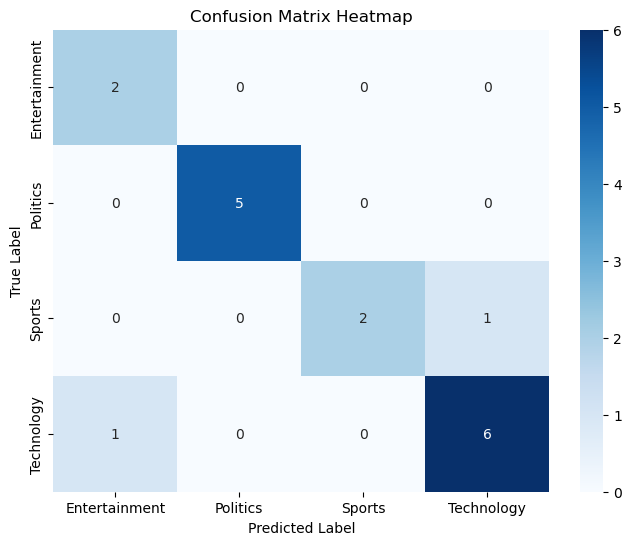

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

### Step 8: Prediction on Unseen Data

In [47]:
user_input = [
    "I love artificial intelligence and machine learning",
    "Central bank chiefs ‘stand in full solidarity’ with Jay Powell",
    "The Golden Globes were calm, scripted and largely apolitical amid a world on fire",
    "Michael B. Jordan said watching ‘Sinners’ made him cry"
             ]

In [48]:
user_input_vectorized = vectorizer.transform(user_input)

In [49]:
predicted_label = model.predict(user_input_vectorized)

In [50]:
print(f"The input text belongs to the '{','.join(predicted_label)}' category.")

The input text belongs to the 'Technology,Technology,Entertainment,Sports' category.
